<a href="https://colab.research.google.com/github/jkrish006/Pandas_case_study/blob/main/Casestudy_unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [58]:
adult=pd.read_csv("/content/adult_dataset.csv")
adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [59]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [60]:
adult.duplicated().sum()

np.int64(16)

In [61]:
adult = adult.drop_duplicates()

In [62]:
adult.shape

(48826, 15)

In [63]:
adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46384.000000,4.882600e+04,48826.000000,48826.000000,48826.000000,46384.000000
mean,38.681528,1.896605e+05,10.078278,1079.421230,87.530988,40.451039
std,13.951072,1.056025e+05,2.570759,7453.214369,403.067466,12.645956
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376170e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [64]:
adult.replace("?", np.nan, inplace=True)

In [65]:
adult.isna().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [66]:
adult["age"]=adult["age"].fillna(adult["age"].median())
adult["hours-per-week"]=adult["hours-per-week"].fillna(adult["hours-per-week"].median())

In [67]:
adult['workclass'] = adult['workclass'].fillna(adult['workclass'].mode()[0])
adult['occupation'] = adult['occupation'].fillna(adult['occupation'].mode()[0])
adult['native-country'] = adult['native-country'].fillna(adult['native-country'].mode()[0])

In [68]:
num_cols=adult.select_dtypes(exclude="object").columns
cat_cols=adult.select_dtypes(include="object").columns

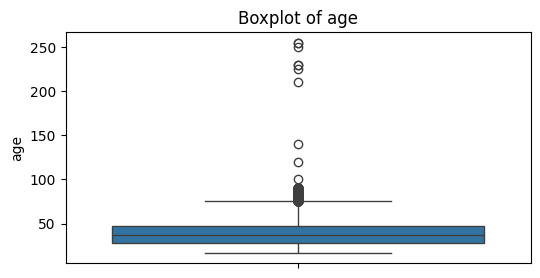

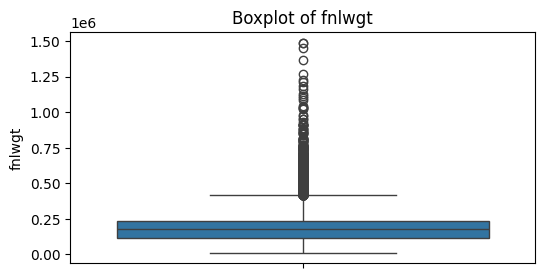

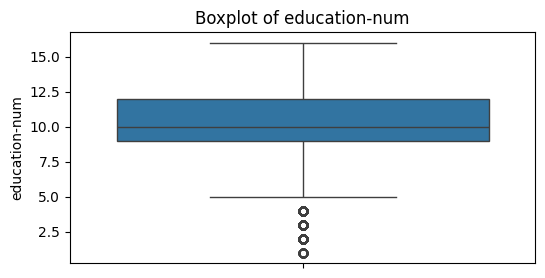

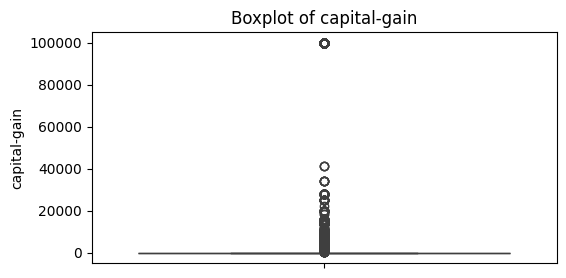

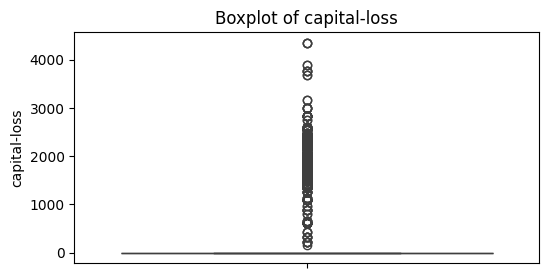

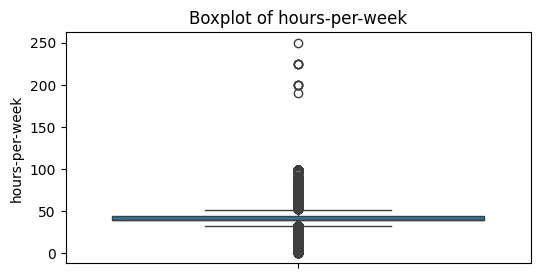

In [69]:
for i in num_cols:
  plt.figure(figsize=(6,3))
  sns.boxplot(y=adult[i])
  plt.title(f"Boxplot of {i}")
  plt.show()


In [70]:
for i in num_cols:
  Q1=adult[i].quantile(0.25)
  Q3=adult[i].quantile(0.75)

  IQR=Q3-Q1

  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  adult[i]=adult[i].clip(lower=lower,upper=upper)

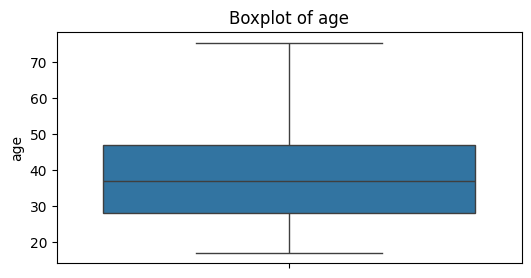

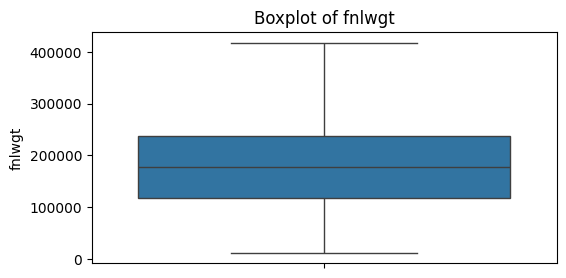

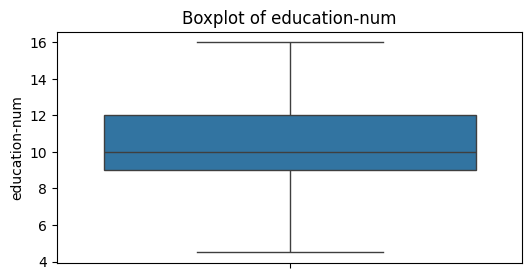

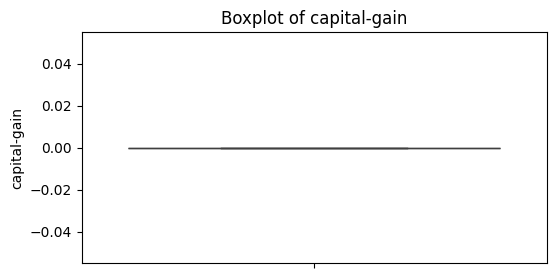

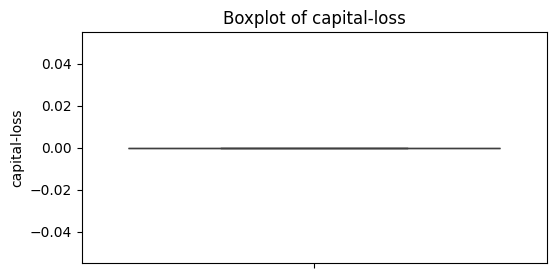

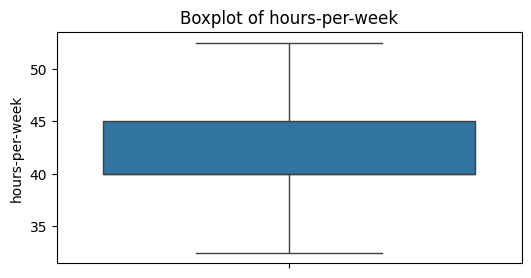

In [71]:
for i in num_cols:
  plt.figure(figsize=(6,3))
  sns.boxplot(y=adult[i])
  plt.title(f"Boxplot of {i}")
  plt.show()

In [72]:
adult.shape

(48826, 15)

In [73]:
X = adult.drop('income', axis=1)

In [74]:
 cat_cols=X.select_dtypes(include="object").columns

In [75]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True,dtype=int)

In [76]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [77]:
X_scaled = pd.DataFrame(X_scaled,columns=X_encoded.columns)

Exploratory Data Analysis

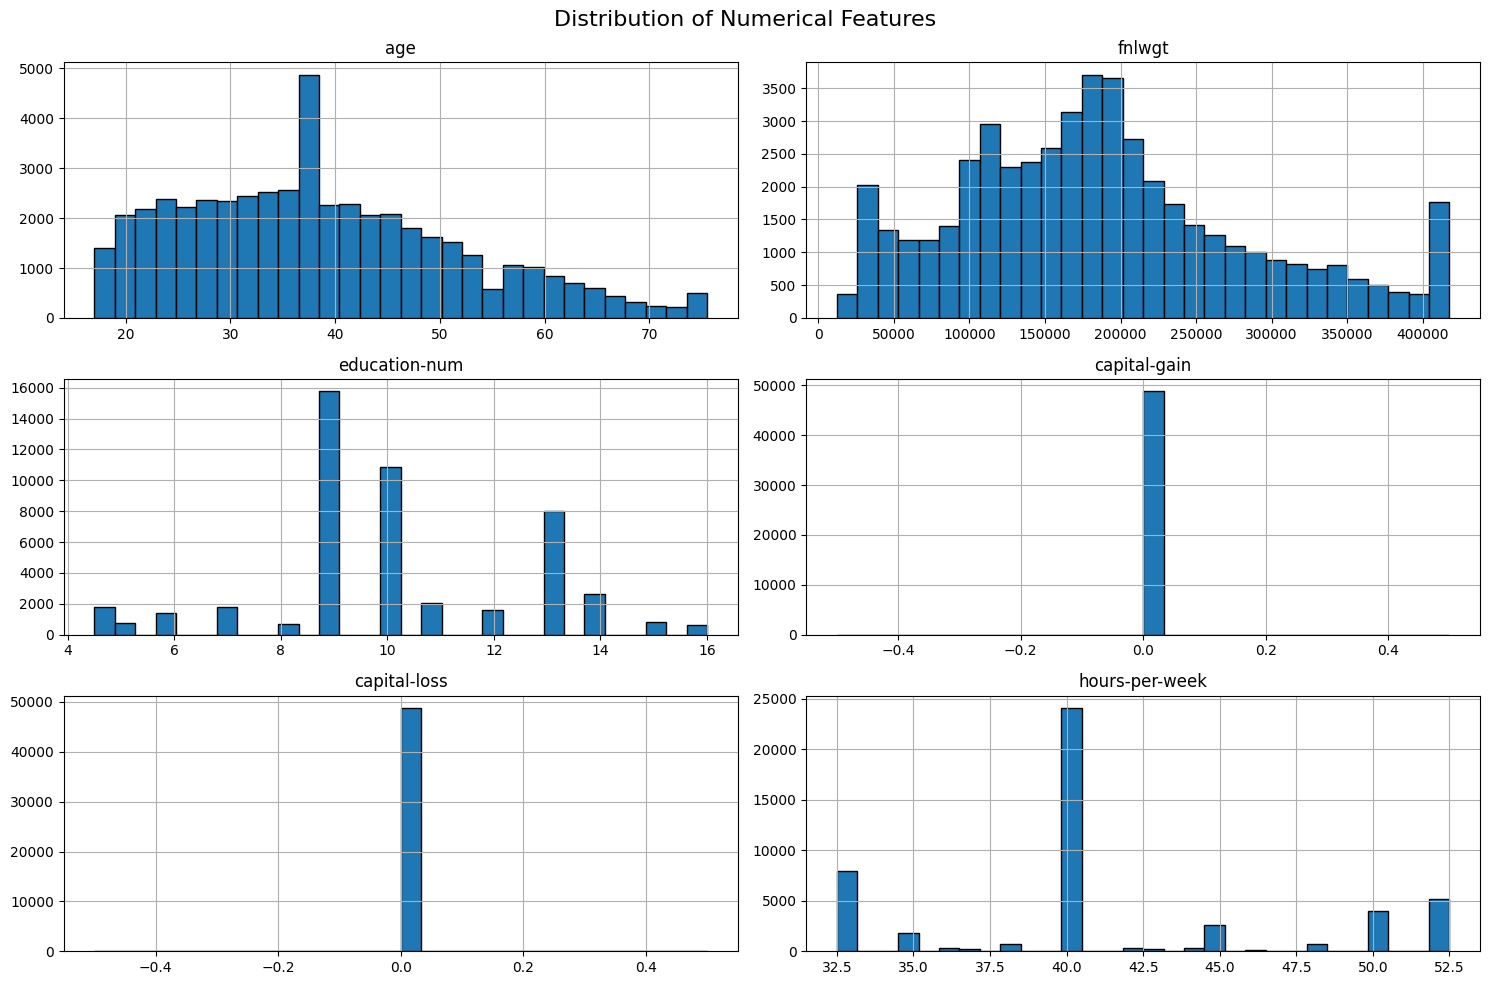

In [78]:
adult[num_cols].hist(
    figsize=(15, 10),
    bins=30,
    edgecolor='black'
)

plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

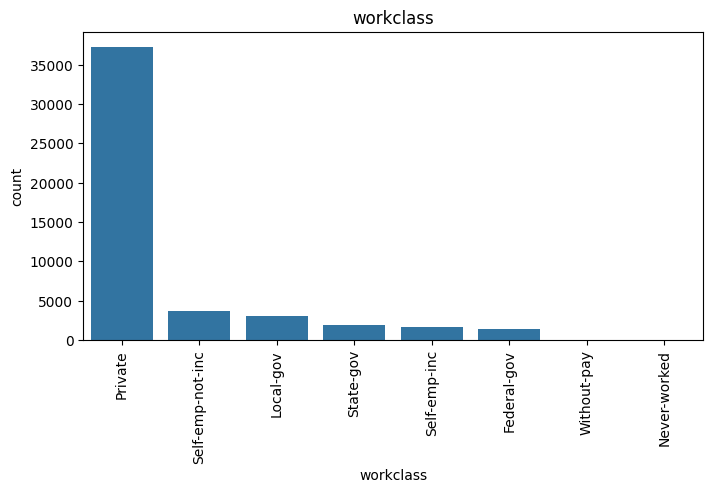

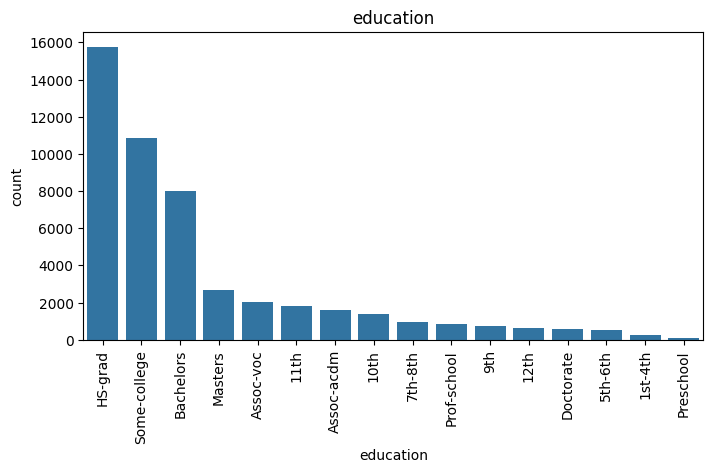

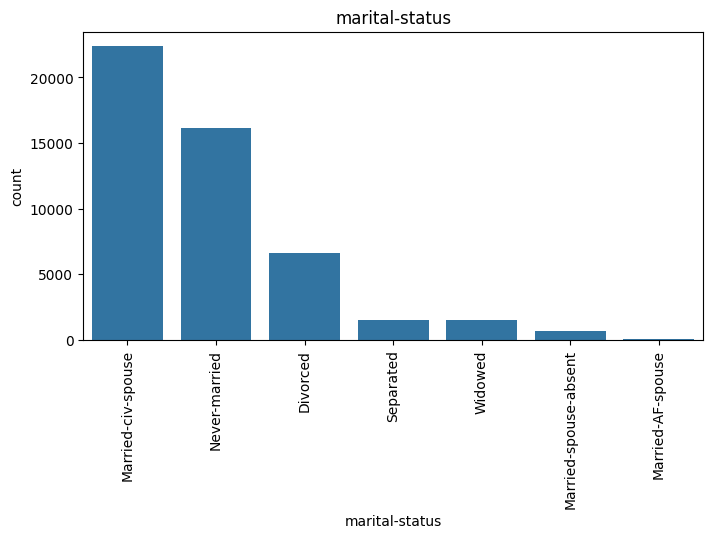

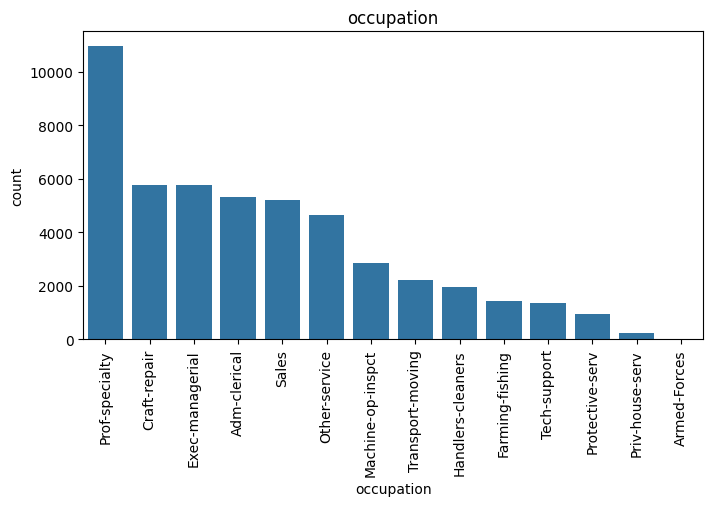

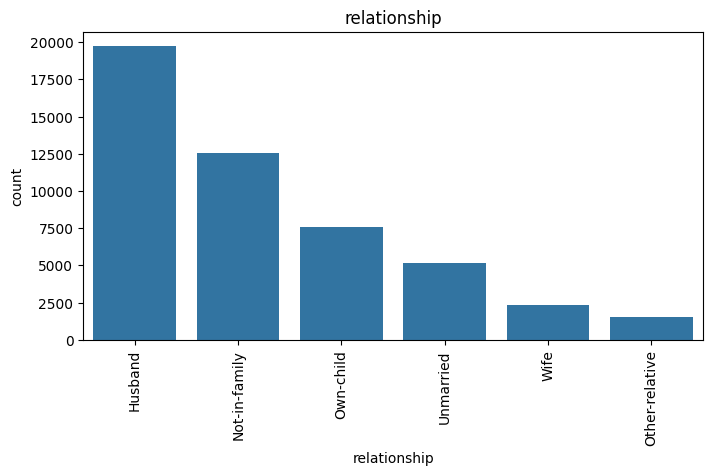

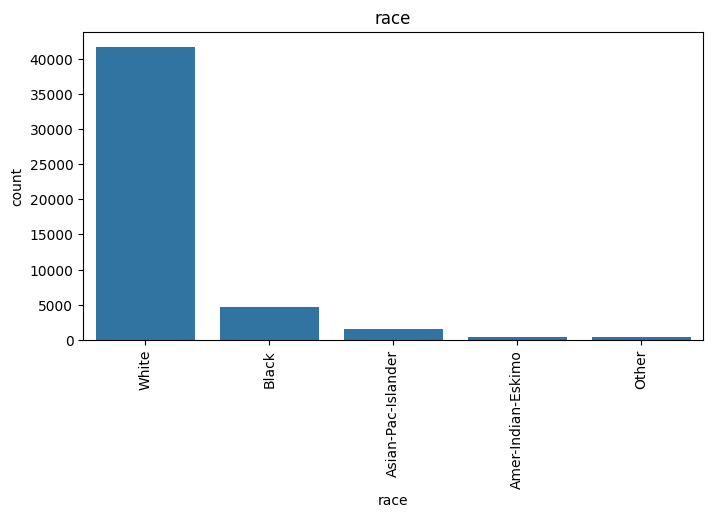

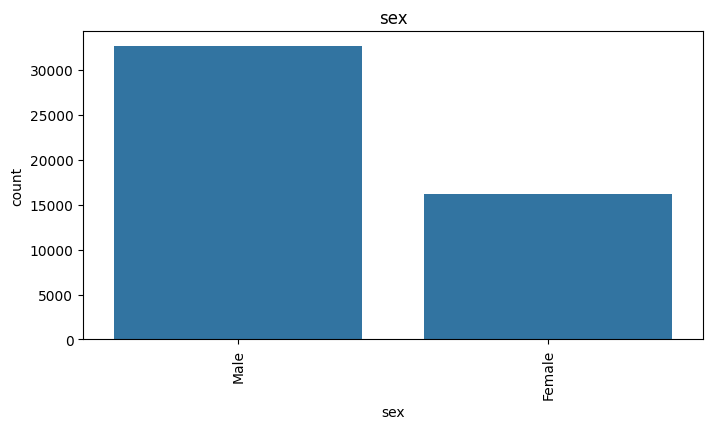

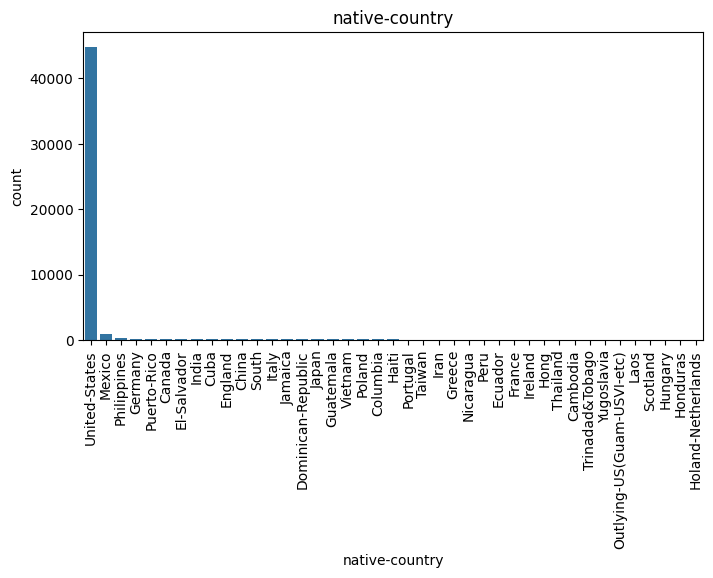

In [79]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=adult,
                  x=col,
                  order=adult[col].value_counts().index)
    plt.xticks(rotation=90)
    plt.title(col)
    plt.show()

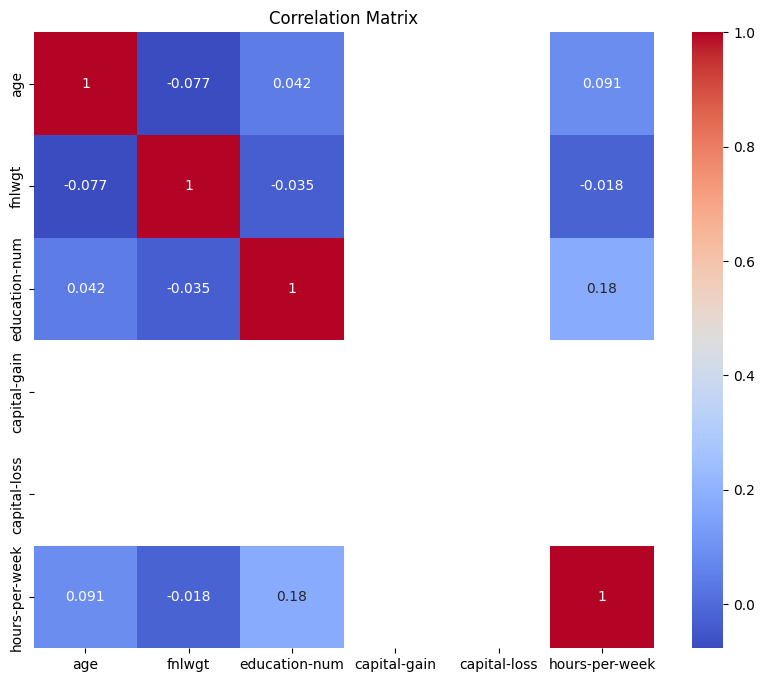

In [80]:
plt.figure(figsize=(10,8))

sns.heatmap(
    adult[num_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [81]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [82]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=X_scaled.index
)

pca_df.head()

,PC1,PC2
0,0.847327,2.631395
1,3.252870,0.509135
2,-0.847290,-0.489289
3,-1.211760,-2.003722
4,0.063531,-0.962933


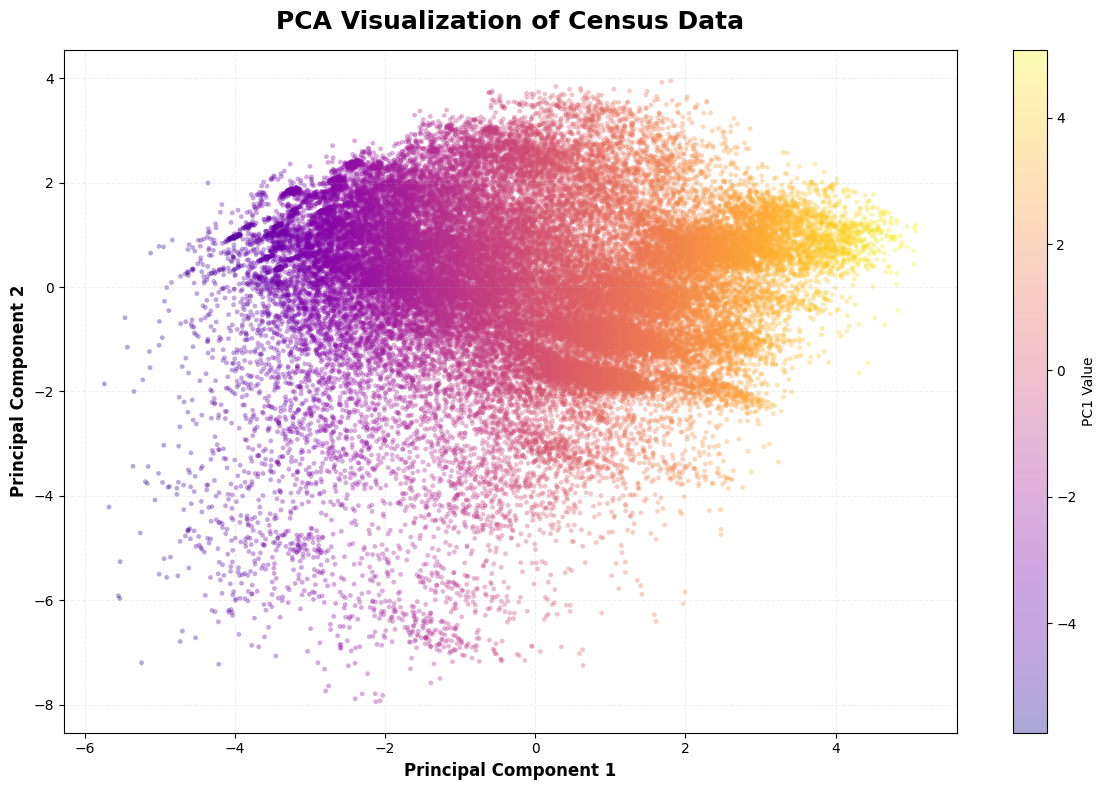

In [83]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['PC1'],
    cmap='plasma',
    s=12,
    alpha=0.35,
    edgecolors='none'
)

plt.colorbar(
    scatter,
    label='PC1 Value'
)

plt.title(
    'PCA Visualization of Census Data',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Principal Component 1',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Principal Component 2',
    fontsize=12,
    fontweight='bold')

plt.grid(alpha=0.2,linestyle='--')

plt.tight_layout()
plt.show()


CLUSTERING

In [84]:
from sklearn.cluster import KMeans

inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

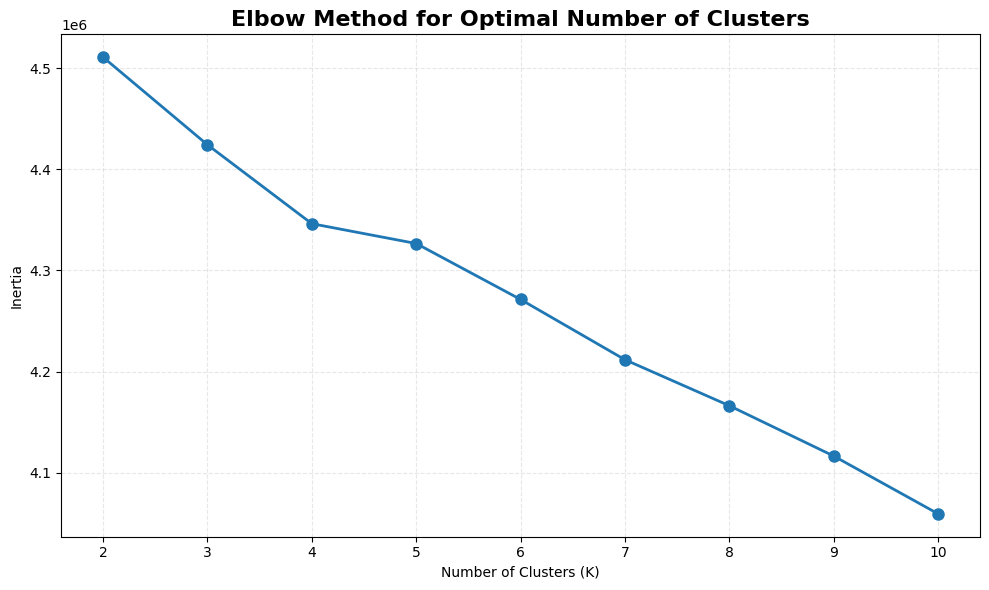

In [85]:
plt.figure(figsize=(10, 6))

plt.plot(
    K,
    inertia,
    marker='o',
    linewidth=2,
    markersize=8)

plt.title('Elbow Method for Optimal Number of Clusters',fontsize=16,fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.xticks(list(K))
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

SILHOUETTE SCORE

In [86]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=10000,
        random_state=42
    )

    silhouette_scores.append(score)

    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.0521
K = 3: Silhouette Score = 0.0473
K = 4: Silhouette Score = 0.0363
K = 5: Silhouette Score = 0.0485
K = 6: Silhouette Score = 0.0143
K = 7: Silhouette Score = 0.0383
K = 8: Silhouette Score = 0.0408
K = 9: Silhouette Score = 0.0262
K = 10: Silhouette Score = 0.0540


In [87]:
final_kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

kmeans_labels = final_kmeans.fit_predict(X_scaled)

adult['KMeans_Cluster'] = kmeans_labels

print(adult['KMeans_Cluster'].value_counts().sort_index())

KMeans_Cluster
0     4387
1     6130
2     3440
3    10585
4      505
5      106
6       74
7    13293
8     9365
9      941
Name: count, dtype: int64


In [88]:
pca_df['KMeans_Cluster'] = kmeans_labels

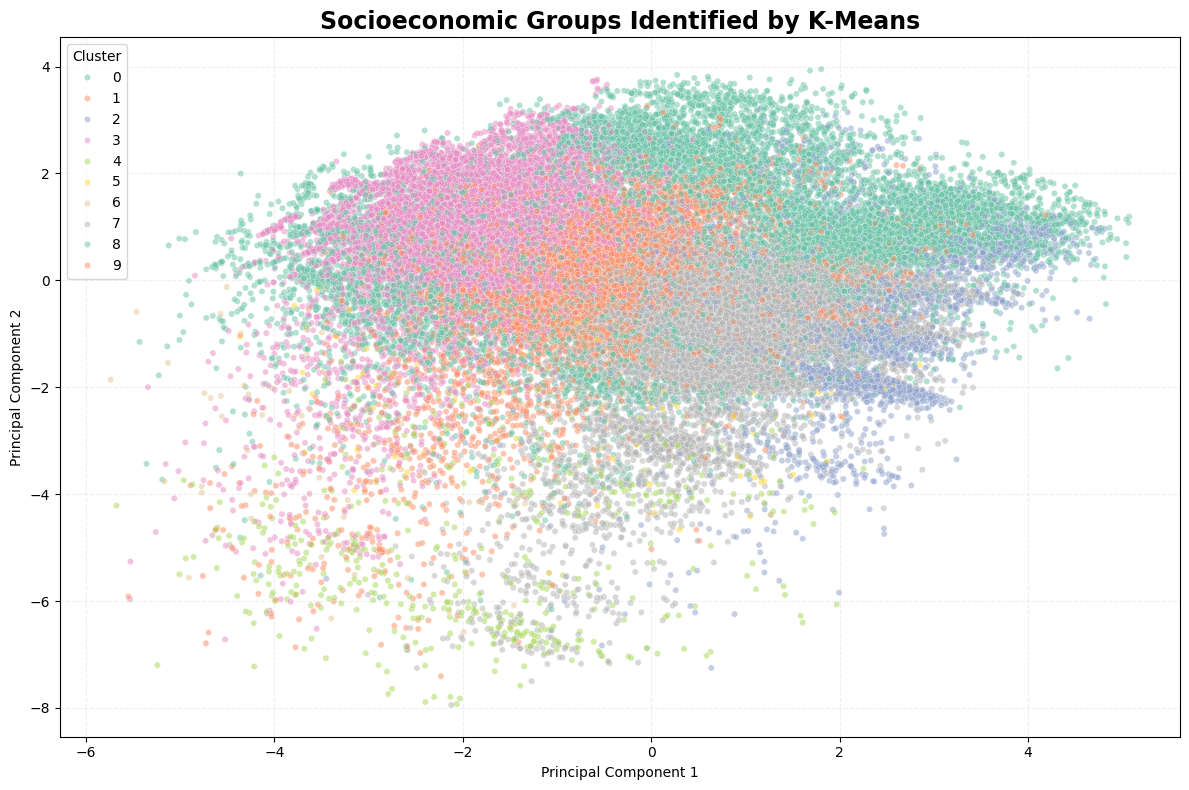

In [89]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='KMeans_Cluster',
    palette='Set2',
    alpha=0.5,
    s=20
)

plt.title(
    'Socioeconomic Groups Identified by K-Means',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(
    title='Cluster',
    loc='best'
)

plt.grid(alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

Agglomerative Clustering

In [90]:
sample_size = 10000

X_sample = X_scaled.sample(n=sample_size,random_state=42)

print("Sample shape:", X_sample.shape)

Sample shape: (10000, 97)


In [91]:
from sklearn.cluster import AgglomerativeClustering

agg_model = AgglomerativeClustering(n_clusters=2,linkage='ward')

agg_labels = agg_model.fit_predict(X_sample)

print("Agglomerative Clustering completed.")

Agglomerative Clustering completed.


In [92]:
print(pd.Series(agg_labels).value_counts().sort_index())

0     836
1    9164
Name: count, dtype: int64


In [93]:
agg_score = silhouette_score(
    X_sample,
    agg_labels,
    sample_size=5000,
    random_state=42
)

print(
    "Agglomerative Silhouette Score:",
    round(agg_score, 4)
)

Agglomerative Silhouette Score: 0.5193


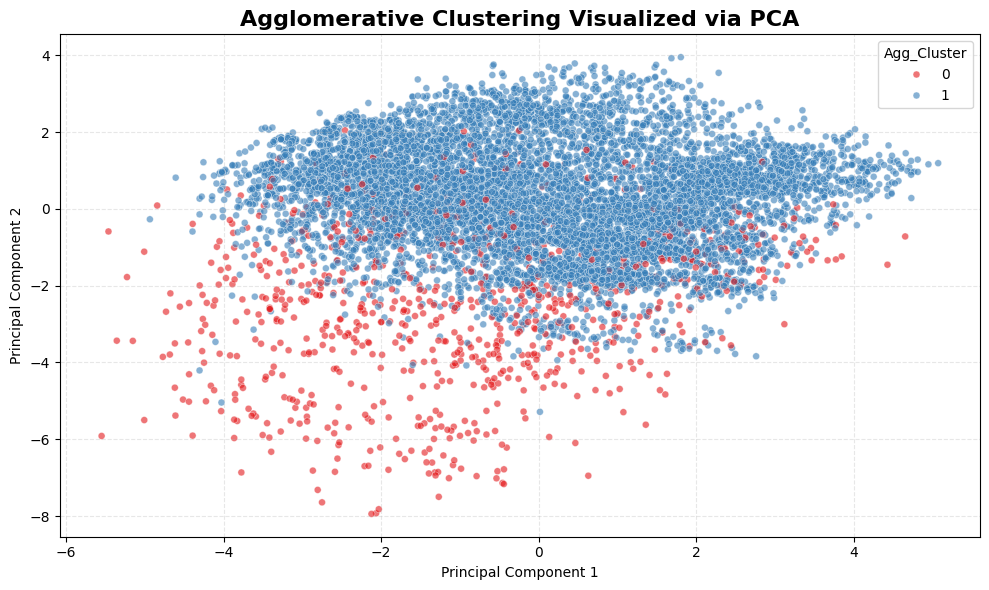

In [94]:
pca_sample = pca.transform(X_sample)
pca_sample_df = pd.DataFrame(pca_sample, columns=['PC1', 'PC2'])
pca_sample_df['Agg_Cluster'] = agg_labels

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_sample_df,
    x='PC1',
    y='PC2',
    hue='Agg_Cluster',
    palette='Set1',
    alpha=0.6,
    s=25
)
plt.title('Agglomerative Clustering Visualized via PCA', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

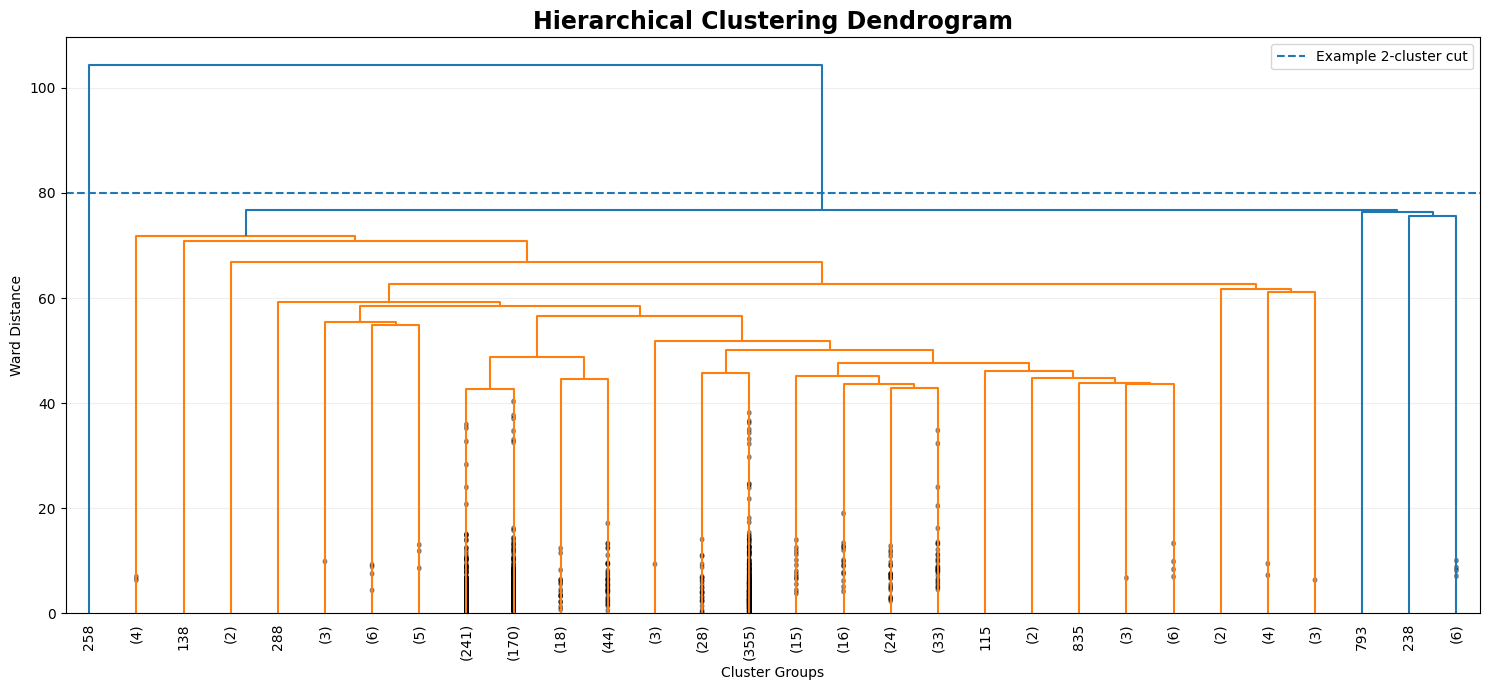

In [95]:
from scipy.cluster.hierarchy import dendrogram, linkage

X_dendro = X_scaled.sample(
    n=1000,
    random_state=42
)

linked = linkage(X_dendro, method='ward')

plt.figure(figsize=(15, 7))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.axhline(
    y=80,
    linestyle='--',
    label='Example 2-cluster cut'
)

plt.title(
    'Hierarchical Clustering Dendrogram',
    fontsize=17,
    fontweight='bold'
)

plt.xlabel('Cluster Groups')
plt.ylabel('Ward Distance')
plt.legend()
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

In [96]:
cluster_profile = adult.copy()
cluster_profile['Cluster'] = kmeans_labels

In [97]:
num_cols = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

cluster_profile.groupby('Cluster')[num_cols].mean().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
Cluster,,,,,,
0,37.52,221327.47,9.56,0.0,0.0,39.73
1,44.38,178788.76,9.29,0.0,0.0,39.61
2,45.14,172764.43,10.35,0.0,0.0,43.24
3,26.40,189414.70,9.36,0.0,0.0,38.45
4,42.82,225882.57,4.50,0.0,0.0,40.04
5,37.21,165287.10,10.76,0.0,0.0,42.83
6,38.32,219141.88,8.86,0.0,0.0,38.64
7,42.25,181883.59,9.07,0.0,0.0,42.21
8,40.95,181618.83,13.50,0.0,0.0,43.46


In [98]:
cat_cols = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country'
]

for col in cat_cols:
    print(f"\n===== {col} =====")
    print(cluster_profile.groupby('Cluster')[col].agg(lambda x: x.mode()[0]))


===== workclass =====
Cluster
0             Private
1             Private
2    Self-emp-not-inc
3             Private
4             Private
5             Private
6             Private
7             Private
8             Private
9           Local-gov
Name: workclass, dtype: object

===== education =====
Cluster
0         HS-grad
1         HS-grad
2         HS-grad
3    Some-college
4         5th-6th
5         HS-grad
6         HS-grad
7         HS-grad
8       Bachelors
9         HS-grad
Name: education, dtype: object

===== marital-status =====
Cluster
0         Never-married
1              Divorced
2    Married-civ-spouse
3         Never-married
4    Married-civ-spouse
5    Married-civ-spouse
6    Married-civ-spouse
7    Married-civ-spouse
8    Married-civ-spouse
9    Married-civ-spouse
Name: marital-status, dtype: object

===== occupation =====
Cluster
0       Prof-specialty
1         Adm-clerical
2         Craft-repair
3       Prof-specialty
4    Machine-op-inspct
5       Prof-spec

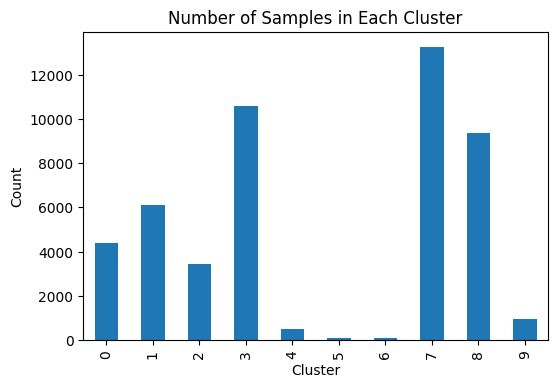

In [99]:
cluster_profile['Cluster'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Number of Samples in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

In [100]:
cluster_profile['income'] = cluster_profile['income'].str.replace('.', '', regex=False)

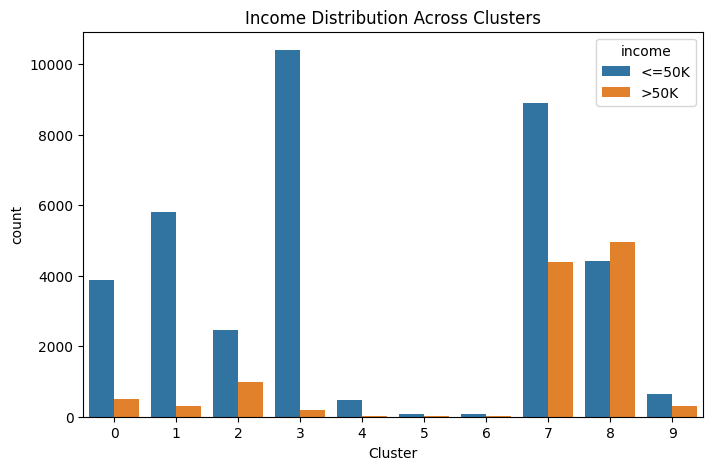

In [101]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=cluster_profile,
    x='Cluster',
    hue='income'
)

plt.title("Income Distribution Across Clusters")
plt.show()

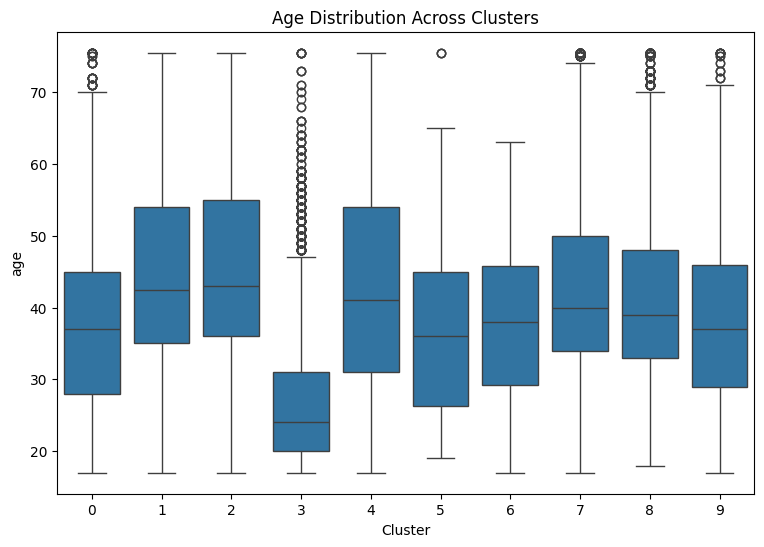

In [102]:
plt.figure(figsize=(9,6))
sns.boxplot(data=cluster_profile, x='Cluster', y='age')
plt.title("Age Distribution Across Clusters")
plt.show()

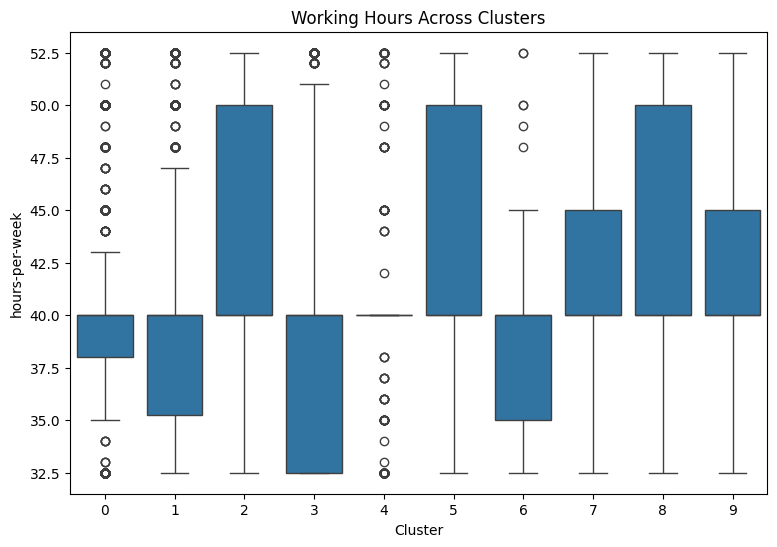

In [103]:
plt.figure(figsize=(9,6))
sns.boxplot(data=cluster_profile, x='Cluster', y='hours-per-week')
plt.title("Working Hours Across Clusters")
plt.show()

In [104]:

pd.crosstab(
    cluster_profile['Cluster'],
    cluster_profile['income'],
    normalize='index'
).round(4)

income,<=50K,>50K
Cluster,,
0,0.8851,0.1149
1,0.9489,0.0511
2,0.7122,0.2878
3,0.9829,0.0171
4,0.9465,0.0535
5,0.8302,0.1698
6,0.8784,0.1216
7,0.6696,0.3304
8,0.4704,0.5296


# Interpretation & Profiling

The K-Means algorithm grouped the Adult Income dataset into 10 distinct clusters based on demographic and work-related characteristics. Income was not used during clustering and was considered only for interpreting the clusters.
Among the 10 clusters, Cluster 8 has the highest proportion of higher-income individuals, while Clusters 1, 3, and 4 contain the largest proportion of lower-income individuals. Therefore, Cluster 8 is highlighted below as an example of cluster interpretation.

## Cluster 8
Cluster 8 has the highest proportion of higher-income individuals.
Approximately 47.03% earn <=50K while 52.96% earn >50K.
This cluster represents the strongest economic group among all clusters.
# Comparison with Actual Income

The income column was not used while creating the clusters.

It was used only after clustering to understand the characteristics of each cluster.

The results show that different clusters have distinct income distributions even though income was not used during training.

Clusters 1, 3 and 4 mainly consist of lower-income individuals, whereas Clusters 7, 8 and 9 contain a comparatively larger proportion of higher-income individuals.

This indicates that the clustering algorithm successfully grouped individuals with similar demographic and economic characteristics.

# Policy Suggestions

## Upskilling Programs

Clusters 1, 3 and 4 may benefit the most from upskilling and vocational training programs because these clusters contain the highest proportion of lower-income individuals.

Providing technical training, certification courses and employment-oriented programs may improve their earning potential.

## Tax Reform

Clusters 7, 8 and 9 contain a relatively larger proportion of higher-income individuals.

Tax policies and incentives can be designed by considering the economic differences between higher-income and lower-income groups.

## Financial Aid and Inclusion

Clusters 1, 3 and 4 may benefit from financial aid and financial inclusion programs.

Possible support includes:

- Education assistance
- Skill development programs
- Affordable loans
- Financial literacy initiatives
- Better access to banking services
- Employment support

These initiatives can help improve the financial condition of economically weaker groups.